In [1]:
import sys
import os
import pandas as pd
import numpy as np
import torch
import copy
import pandas as pd
import torch
import yaml
from enviroment import Stock_Env
from agent import PPO
from grpo import test_grpo

Current working directory: /workspace/grpo_notarn_softmax


In [2]:
def set_seed(seed):
    # random.seed(seed)
    # np.random.seed(seed)
    torch.manual_seed(seed)
    # torch.cuda.manual_seed(seed)
    # torch.cuda.manual_seed_all(seed)  # Multi-GPU 환경 고려
    # torch.backends.cudnn.deterministic = True
    # torch.backends.cudnn.benchmark = False
    print(f"Random seed set to: {seed}")

SEED = 42
set_seed(SEED)

with open("./config/test_config.yaml", "r") as f:
    config = yaml.safe_load(f)
train_data_path = "../data/train_v1.csv"
test_data_path = "../data/test_v1.csv"
test_pt = "../data/no_tran_test_tensor_dict_v2.pt"

device = torch.device(config.get("device", "cuda:0"))
config["device"] = device

train_df = pd.read_csv(train_data_path, index_col=0)
test_df = pd.read_csv(test_data_path, index_col=0)
test_all_df = pd.concat([train_df, test_df], axis=0)
test_all_df.reset_index(drop=True, inplace=True)
test_all_df.set_index("date", inplace=True)

test_tensor = torch.load(test_pt, map_location=device)
traj_len ="1m"
update_interval = config["update_interval_map"].get(traj_len, 60)
config["update_interval"] = update_interval
config["batch_samples"] = config["batch_samples"].get(traj_len, 5)
env = Stock_Env(config=config, states=test_tensor, real_df=test_all_df, eval=True)
agent = PPO(env, eval=True)
import os
model_path =  "model/5d/5d_actor_lr1e-06_clip_grad1_epslion_0.1batch_samples_256_mu50_num_group128_num_steps5_reward_cond_sharpe_grpo_model.pth"
agent.load(model_path)
model_return, strategy_returns, weight_rebal = test_grpo(env, agent)

Random seed set to: 42


/tmp/ipykernel_1777943/2021966549.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  test_tensor = torch.load(test_pt, map_location=device)
/workspace/grpo_notarn_softmax/

model/5d/5d_actor_lr1e-06_clip_grad1_epslion_0.1batch_samples_256_mu50_num_group128_num_steps5_reward_cond_sharpe_grpo_model.pth loaded.


/opt/conda/lib/python3.11/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


최적화 실패. 균등 포트폴리오로 fallback.
최적화 실패. 균등 포트폴리오로 fallback.
최적화 실패. 균등 포트폴리오로 fallback.
최적화 실패. 균등 포트폴리오로 fallback.
최적화 실패. 균등 포트폴리오로 fallback.
tensor(0.5537) tensor(0.2024)
action_mean tensor([[-0.1378,  0.0034,  0.4075, -0.2922, -0.0938,  0.1943]],
       grad_fn=<AddmmBackward0>)
Day: 2010-01-04 ~ 2010-02-01
top3_action :  {'RP': np.float32(0.13942432), 'Min_Var': np.float32(0.1605642), 'Mean_Var_max_sharpe': np.float32(0.24050987), 'DAA': np.float32(0.11947341), 'PAA': np.float32(0.14569184), 'GTAA': np.float32(0.1943364)}
tensor(0.5094) tensor(0.2028)
action_mean tensor([[-0.1459, -0.0090,  0.3886, -0.3212, -0.0599,  0.1906]],
       grad_fn=<AddmmBackward0>)
Day: 2010-02-02 ~ 2010-03-02
top3_action :  {'RP': np.float32(0.13922854), 'Min_Var': np.float32(0.15965085), 'Mean_Var_max_sharpe': np.float32(0.237607), 'DAA': np.float32(0.116841175), 'PAA': np.float32(0.15174127), 'GTAA': np.float32(0.19493116)}
tensor(0.5719) tensor(0.2425)
action_mean tensor([[-0.1141, -0.0613,  0.3240, -0.

/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [3]:
model_return.rename(columns={0: "Model"}, inplace=True)

In [4]:
strategy_returns["Model"] = model_return["Model"]

In [5]:
strategy_returns

{'RP': 2010-01-04    0.016649
 2010-01-05    0.004986
 2010-01-06    0.006592
 2010-01-07   -0.005392
 2010-01-08    0.007591
                 ...   
 2023-12-22    0.002231
 2023-12-26    0.004316
 2023-12-27    0.005480
 2023-12-28   -0.003288
 2023-12-29    0.002107
 Length: 3521, dtype: float64,
 'Min_Var': 2010-01-04    0.011660
 2010-01-05    0.009649
 2010-01-06    0.006701
 2010-01-07   -0.003165
 2010-01-08    0.006109
                 ...   
 2023-12-22    0.002270
 2023-12-26   -0.000425
 2023-12-27    0.003921
 2023-12-28    0.002344
 2023-12-29    0.002454
 Length: 3521, dtype: float64,
 'Mean_Var_max_sharpe': 2010-01-04    0.011299
 2010-01-05    0.011490
 2010-01-06    0.008373
 2010-01-07   -0.004109
 2010-01-08    0.003505
                 ...   
 2023-12-22    0.001819
 2023-12-26    0.005713
 2023-12-27    0.003802
 2023-12-28   -0.007124
 2023-12-29    0.001925
 Length: 3521, dtype: float64,
 'DAA': 2010-01-04    0.022019
 2010-01-05    0.001920
 2010-01-06    0.012

In [6]:
def calculate_annual_return(returns, annual_factor=252):
    returns = np.array(returns, dtype=np.float64)
    cumulative = np.prod(1 + returns)
    n_periods = len(returns)
    return cumulative ** (annual_factor / n_periods) - 1


def calculate_max_drawdown(returns):
    returns = np.array(returns, dtype=np.float64)
    cumulative_returns = np.cumprod(1 + returns)
    running_max = np.maximum.accumulate(cumulative_returns)
    drawdowns = (cumulative_returns - running_max) / running_max
    return abs(np.min(drawdowns))

def calculate_volatility(returns, annual_factor=252):
    returns = np.asarray(returns)
    return np.std(returns, ddof=1) * np.sqrt(annual_factor)


def calculate_sharpe_ratio(returns, risk_free_rate=0.02, annual_factor=252):
    returns = np.array(returns, dtype=np.float64)
    annual_return = calculate_annual_return(returns, annual_factor)
    annual_std_dev = calculate_volatility(returns, annual_factor)
    excess_return =  (annual_return - risk_free_rate) 
    # 연환산 수익률과 표준편차
    return excess_return / annual_std_dev if annual_std_dev != 0 else 0.0


def calculate_cumulative_return(returns):
    returns = np.array(returns, dtype=np.float64)
    return np.prod(1 + returns) - 1

def calculate_volatility(returns, annual_factor=252):
    returns = np.asarray(returns)
    return np.std(returns, ddof=1) * np.sqrt(annual_factor)


# 성과 지표 계산 함수 (파라미터화)
def calculate_performance_metrics(returns, annual_factor=252, risk_free_rate=0.0):
    cumulative_returns = (1 + returns).cumprod()
    # cagr = calculate_cagr(returns, annual_factor)
    annual_return = calculate_annual_return(returns, annual_factor)
    sharpe_ratio = calculate_sharpe_ratio(returns, risk_free_rate, annual_factor)
    mdd = calculate_max_drawdown(returns)
    volatility = calculate_volatility(returns, annual_factor)

    return {
        'Cumulative Return': cumulative_returns.iloc[-1] - 1,
        'Annual Return': annual_return,
        # 'CAGR': cagr,
        'Volatility': volatility,
        'Sharpe Ratio': sharpe_ratio,
        'MDD': mdd
    }


# 성과 지표 요약 생성 함수 (파라미터 전달)
def get_performance_summary(returns_dict, annual_factor=252, risk_free_rate=0.0):
    metrics_df = pd.DataFrame()
    for name, returns in returns_dict.items():
        metrics_df[name] = calculate_performance_metrics(returns, annual_factor, risk_free_rate)
    return metrics_df.T


# 성과 지표 요약 생성 함수 (파라미터 전달)
def get_performance_summary(returns_dict, annual_factor=252, risk_free_rate=0.0):
    metrics_df = pd.DataFrame()
    for name, returns in returns_dict.items():
        metrics_df[name] = calculate_performance_metrics(returns, annual_factor, risk_free_rate)
    return metrics_df.T


import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import numpy as np

def plot_cumulative_returns(returns_dict, title='Cumulative Returns', y_range=(0.0, 5), test_start_date=None):
    plt.figure(figsize=(14, 8))

    # 전략별 색깔 테이블 (고정)
    color_map = {
        'rp': 'skyblue',
        'min_var': 'darkorange',
        'mean_var_max_sharpe': 'limegreen',
        'daa': 'crimson',
        'paa': 'purple',
        'gtaa': 'sienna',
        'equal': 'black',
        'equal weight': 'black',
        'model': '#4169E1',  # royalblue
    }

    for strategy_name, daily_returns in returns_dict.items():
        cumulative_returns = (1 + daily_returns).cumprod()
        
        lower_name = strategy_name.lower()
        color = color_map.get(lower_name, None)

        if color:
            plt.plot(cumulative_returns.index.astype(str), cumulative_returns.values,
                     label=f'Strategy - {strategy_name}', color=color, linewidth=2.5 if lower_name in ['equal', 'equal weight', 'model'] else 1.8)
        else:
            plt.plot(cumulative_returns.index.astype(str), cumulative_returns.values,
                     label=f'Strategy - {strategy_name}', linewidth=1.5)

    if test_start_date:
        plt.axvline(x=test_start_date, color='red', linestyle='--', linewidth=2, label='Test Start')

    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Cumulative Returns')
    plt.ylim(y_range)
    plt.xticks(np.arange(0, len(cumulative_returns.index), 60),
               cumulative_returns.index.astype(str)[::60], rotation=45)
    plt.legend(loc='upper left', fontsize='small', ncol=2)
    plt.grid(True)
    plt.tight_layout()
    plt.show()




In [7]:
strategy_returns

{'RP': 2010-01-04    0.016649
 2010-01-05    0.004986
 2010-01-06    0.006592
 2010-01-07   -0.005392
 2010-01-08    0.007591
                 ...   
 2023-12-22    0.002231
 2023-12-26    0.004316
 2023-12-27    0.005480
 2023-12-28   -0.003288
 2023-12-29    0.002107
 Length: 3521, dtype: float64,
 'Min_Var': 2010-01-04    0.011660
 2010-01-05    0.009649
 2010-01-06    0.006701
 2010-01-07   -0.003165
 2010-01-08    0.006109
                 ...   
 2023-12-22    0.002270
 2023-12-26   -0.000425
 2023-12-27    0.003921
 2023-12-28    0.002344
 2023-12-29    0.002454
 Length: 3521, dtype: float64,
 'Mean_Var_max_sharpe': 2010-01-04    0.011299
 2010-01-05    0.011490
 2010-01-06    0.008373
 2010-01-07   -0.004109
 2010-01-08    0.003505
                 ...   
 2023-12-22    0.001819
 2023-12-26    0.005713
 2023-12-27    0.003802
 2023-12-28   -0.007124
 2023-12-29    0.001925
 Length: 3521, dtype: float64,
 'DAA': 2010-01-04    0.022019
 2010-01-05    0.001920
 2010-01-06    0.012

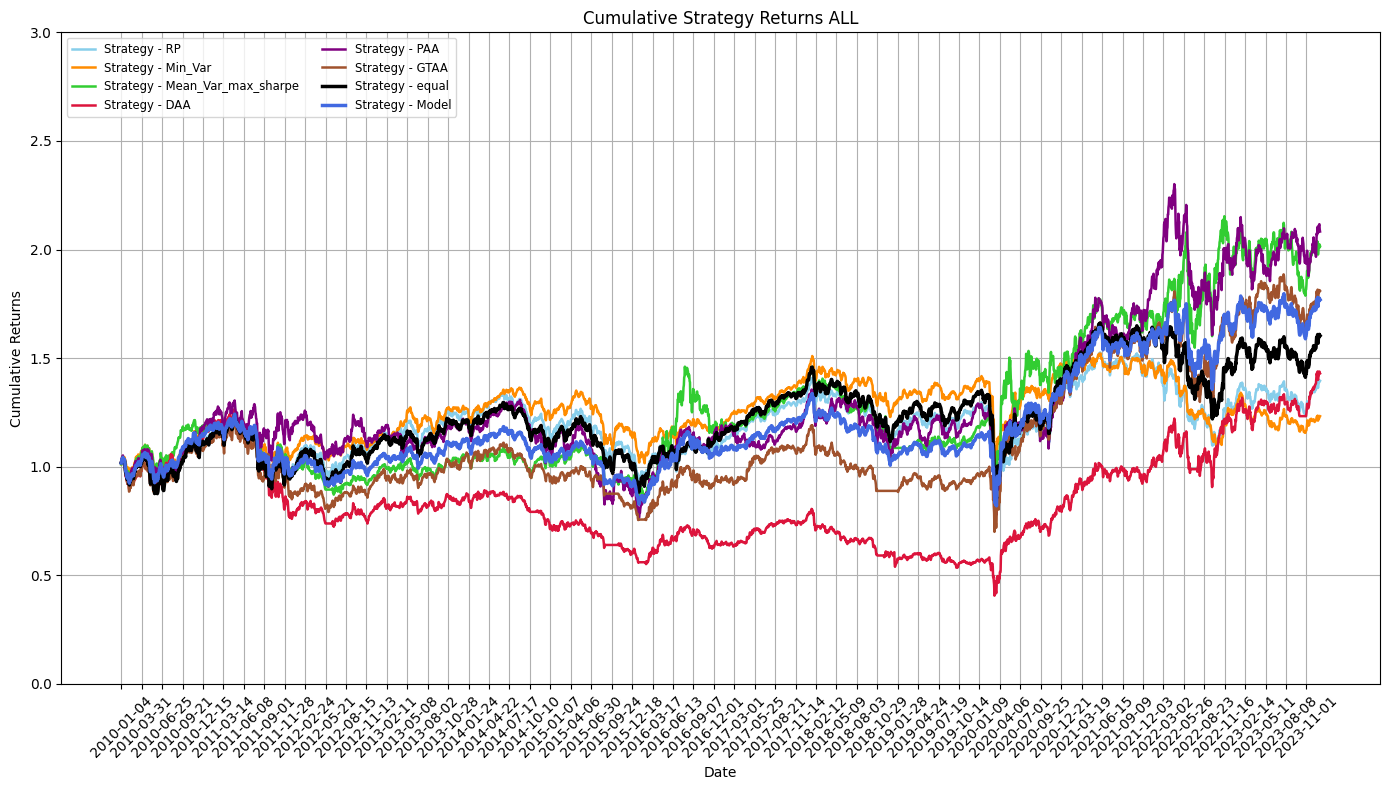

In [9]:
plot_cumulative_returns(strategy_returns, "Cumulative Strategy Returns ALL", (0.0, 3))

In [5]:
(1+0.754369)**(252/3521)

1.0410506909938637

In [10]:
metrics_summary = get_performance_summary(
    strategy_returns,
    annual_factor=252,
    risk_free_rate=0.0
)

display(metrics_summary)


,Cumulative Return,Annual Return,Volatility,Sharpe Ratio,MDD
RP,0.395391,0.024132,0.149653,0.161254,0.408707
Min_Var,0.232809,0.015092,0.114683,0.131599,0.342306
Mean_Var_max_sharpe,1.013739,0.051375,0.196470,0.261491,0.367125
DAA,0.429726,0.025915,0.191678,0.135202,0.679107
PAA,1.082978,0.053922,0.215588,0.250116,0.424889
GTAA,0.808958,0.043336,0.193134,0.224385,0.423676
equal,0.602833,0.034342,0.165194,0.207886,0.414096
Model,0.768436,0.041646,0.154489,0.269572,0.386521


In [11]:
strategy_returns

{'RP': 2010-01-04    0.016649
 2010-01-05    0.004986
 2010-01-06    0.006592
 2010-01-07   -0.005392
 2010-01-08    0.007591
                 ...   
 2023-12-22    0.002231
 2023-12-26    0.004316
 2023-12-27    0.005480
 2023-12-28   -0.003288
 2023-12-29    0.002107
 Length: 3521, dtype: float64,
 'Min_Var': 2010-01-04    0.011660
 2010-01-05    0.009649
 2010-01-06    0.006701
 2010-01-07   -0.003165
 2010-01-08    0.006109
                 ...   
 2023-12-22    0.002270
 2023-12-26   -0.000425
 2023-12-27    0.003921
 2023-12-28    0.002344
 2023-12-29    0.002454
 Length: 3521, dtype: float64,
 'Mean_Var_max_sharpe': 2010-01-04    0.011299
 2010-01-05    0.011490
 2010-01-06    0.008373
 2010-01-07   -0.004109
 2010-01-08    0.003505
                 ...   
 2023-12-22    0.001819
 2023-12-26    0.005713
 2023-12-27    0.003802
 2023-12-28   -0.007124
 2023-12-29    0.001925
 Length: 3521, dtype: float64,
 'DAA': 2010-01-04    0.022019
 2010-01-05    0.001920
 2010-01-06    0.012

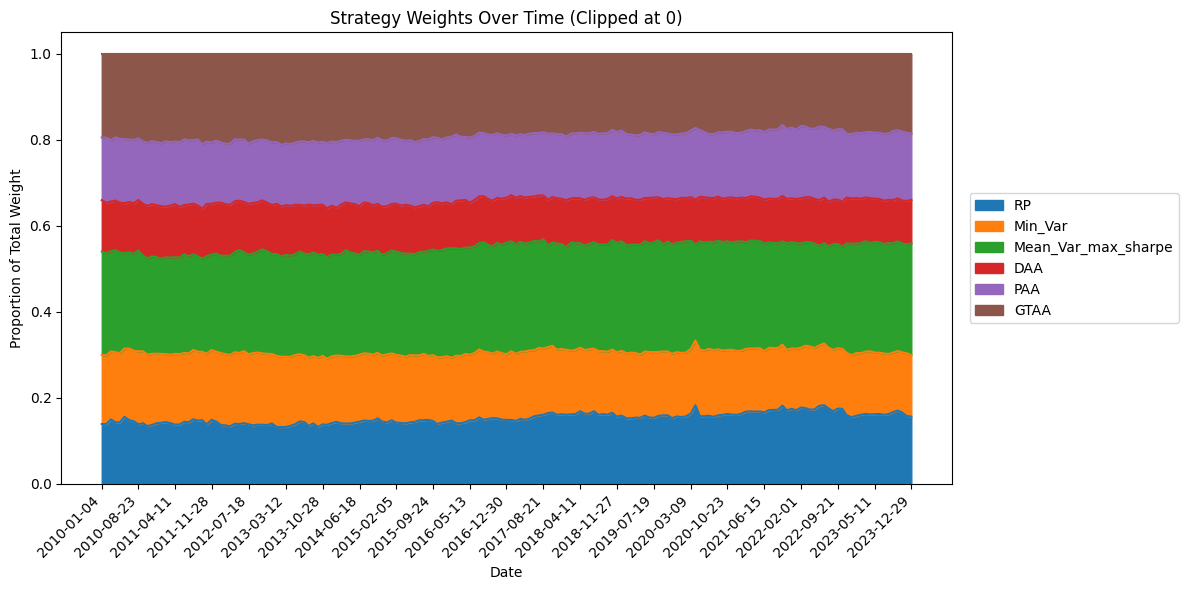

In [12]:
# X축 레이블이 문자열로 되어 있어서 발생한 오류 방지를 위해 인덱스를 datetime으로 변환
# weight_rebal = weight_ratio_df_clipped.copy()
weight_rebal.index = pd.to_datetime(weight_rebal.index)

# X축 눈금 설정
fig, ax = plt.subplots(figsize=(12, 6))
weight_rebal.plot.area(ax=ax)

ax.set_title('Strategy Weights Over Time (Clipped at 0)')
ax.set_ylabel('Proportion of Total Weight')
ax.set_xlabel('Date')

# 전체 날짜 중 일부만 xtick으로 표시 (예: 10일 간격)
step = max(1, len(weight_rebal.index) // 20)
selected_ticks = weight_rebal.index[::step]

ax.set_xticks(selected_ticks)
ax.set_xticklabels(selected_ticks.strftime('%Y-%m-%d'), rotation=45)

ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)
plt.tight_layout()
plt.show()


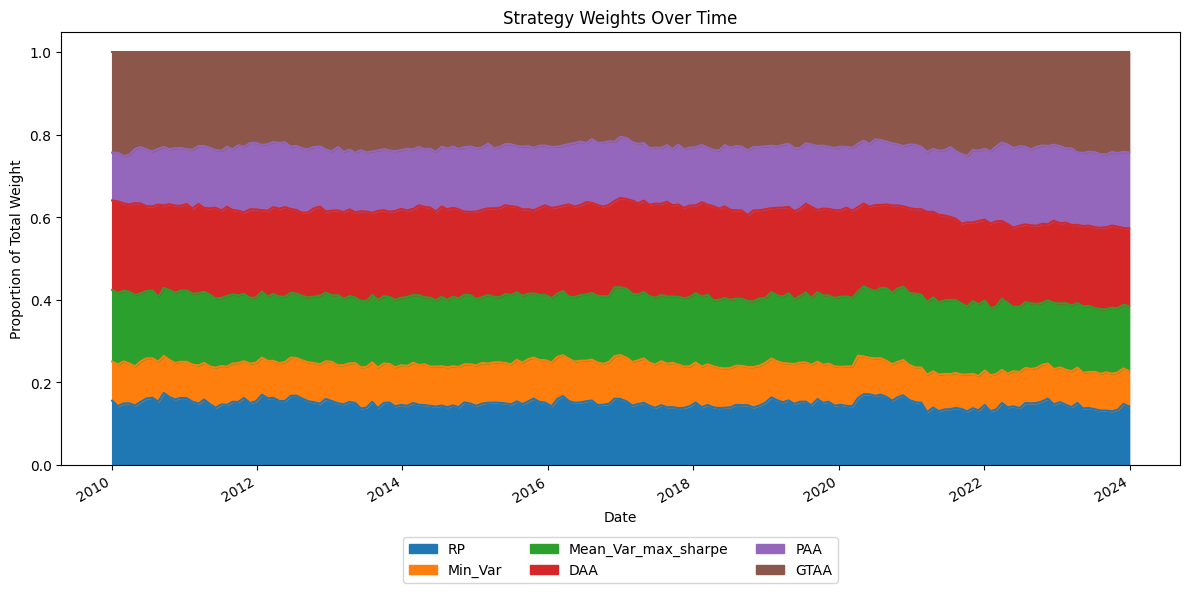

In [15]:
import matplotlib.pyplot as plt

# 누적 비중 시각화를 위한 준비
fig, ax = plt.subplots(figsize=(12, 6))

# 누적 stacked area plot
weight_rebal.plot.area(ax=ax)

ax.set_title('Strategy Weights Over Time')
ax.set_ylabel('Proportion of Total Weight')
ax.set_xlabel('Date')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.tight_layout()

plt.show()
